<div style="background:linear-gradient(135deg,#0f172a 0%,#1e3a8a 50%,#312e81 100%);padding:40px;border-radius:14px;color:white;text-align:center;font-family:'Segoe UI',sans-serif;">

<h1 style="margin:0;font-size:42px;letter-spacing:1px;">Classical ML for Vision</h1>
<h3 style="margin:8px 0 18px 0;font-weight:300;opacity:0.9;">Notebook 05 - HOG, SVM, Bag-of-Visual-Words & a Real Detector</h3>

<p style="font-size:15px;opacity:0.85;margin:0;">Computer Vision Series - for AI Students & AI Engineers</p>
<p style="font-size:13px;opacity:0.7;margin-top:6px;">Prereqs: Notebooks 01-04</p>

</div>

---

> **Note:** All content in this notebook (text, structure, code) is for educational purposes. Always verify critical facts and run code in your own environment.

---

### Where we are in the series

| # | Notebook | Status |
|---|---|---|
| 01 | Foundations, History & Modern Toolkit | Done |
| 02 | Image Fundamentals & NumPy/OpenCV Core | Done |
| 03 | Image Processing & Filtering | Done |
| 04 | Feature Detection (SIFT, ORB, Harris) | Done |
| **05** | **Classical ML for Vision** | *You are here* |
| 06 | Deep Learning for CV - CNNs from scratch | upcoming |
| 07+ | Modern CNNs, Detection, Segmentation, Generative, VLMs | upcoming |

---

### What you'll master in this notebook

1. **Why classical ML still matters in 2026** - small data, edge devices, interpretability
2. **HOG (Histogram of Oriented Gradients)** - the descriptor that beat everything for years
3. **K-Nearest Neighbors on raw pixels** - the dumbest baseline (and what's wrong with it)
4. **HOG + SVM** - the classical recipe that powered pedestrian detection
5. **Bag-of-Visual-Words (BoVW)** - turn local features into global image descriptors
6. **Sliding-window detection** - the OG object detection trick
7. **Capstone** - train a real digit classifier on synthetic data and a small "shape detector"

> Every section is runnable and uses synthetic data so the notebook works offline.


## 1. Why Bother With Classical ML in 2026?

Deep learning has won most CV benchmarks. But classical ML is still the right tool when:

| Situation | Why classical wins |
|---|---|
| **Tiny dataset** (< 100 samples per class) | A CNN will overfit; SVM on HOG won't |
| **Edge devices** (microcontrollers, < 1 MB RAM) | A YOLO model is too big; HOG+SVM fits in kilobytes |
| **Latency critical** (< 1 ms) | Classical methods are hard to beat |
| **Interpretability required** (medical, legal) | You can read what HOG measures; you can't read what a CNN measures |
| **No GPU** | Classical pipelines run on a Raspberry Pi |
| **Quick prototype** | A 30-line scikit-learn script can validate your idea before you spin up training infra |

### The classical CV recipe

```
Image  ->  Feature extraction  ->  Classifier
            (HOG, SIFT, color)      (SVM, KNN, Random Forest)
```

You hand-design the features; the model learns the **decision boundary**, not the features themselves. That's the key difference from deep learning, where the network learns features and decisions jointly.


In [1]:
# Verify the toolkit
# uv add opencv-python-headless numpy matplotlib scikit-learn scikit-image

import sys
import numpy as np
import cv2
import matplotlib.pyplot as plt

import sklearn
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import skimage
from skimage.feature import hog

print(f"Python:       {sys.version.split()[0]}")
print(f"NumPy:        {np.__version__}")
print(f"OpenCV:       {cv2.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"scikit-image: {skimage.__version__}")
print("\nClassical ML toolkit ready.")

Python:       3.11.14
NumPy:        2.4.4
OpenCV:       4.13.0
scikit-learn: 1.8.0
scikit-image: 0.26.0

Classical ML toolkit ready.


## 2. HOG - Histogram of Oriented Gradients

HOG (Dalal & Triggs, 2005) was the descriptor that revolutionized pedestrian detection. It captures **shape** by counting gradient directions in a grid of cells.

### How HOG works (5 clean steps)

```
1. Compute gradients (Gx, Gy) over the image
2. Divide image into small cells (typically 8x8 px)
3. Per cell: build a histogram of gradient ORIENTATIONS, weighted by MAGNITUDE
4. Normalize histograms in larger blocks (typically 2x2 cells) for lighting invariance
5. Concatenate all histograms -> one big feature vector
```

### Why HOG works so well for shape

- **Orientation, not position** - small spatial shifts inside a cell don't change the histogram much
- **Block normalization** - removes the effect of lighting and contrast
- **Compact and dense** - thousands of features, but each is a simple, interpretable count

A 64x128 pedestrian window with default HOG settings produces a **3780-dim** feature vector.


Image shape:        (128, 64)
HOG feature length: 3780 dimensions
First 10 features:  [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


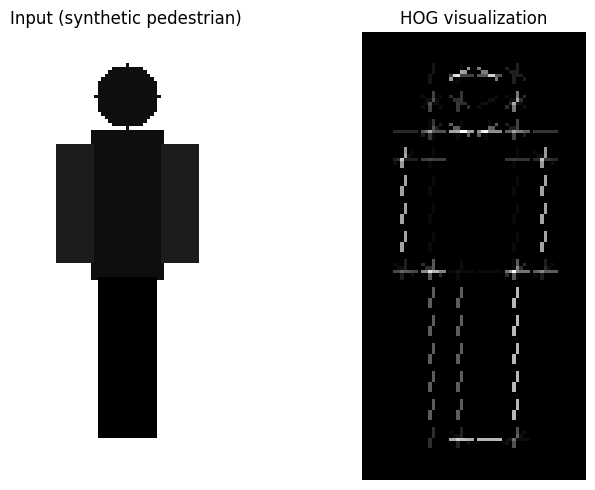


The bright lines show the dominant gradient orientation in each cell.
Notice they trace the silhouette - that's why HOG captures shape so well.


In [2]:
# Build a synthetic 'pedestrian-like' silhouette to extract HOG features from
img = np.full((128, 64), 230, dtype=np.uint8)
# Head
cv2.circle(img, (32, 18), 9, 60, -1)
# Body / torso
cv2.rectangle(img, (22, 28), (42, 70), 60, -1)
# Arms
cv2.rectangle(img, (12, 32), (22, 65), 70, -1)
cv2.rectangle(img, (42, 32), (52, 65), 70, -1)
# Legs
cv2.rectangle(img, (24, 70), (32, 115), 50, -1)
cv2.rectangle(img, (32, 70), (40, 115), 50, -1)

# Compute HOG features + visualization with skimage
fd, hog_image = hog(
    img,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2),
    block_norm="L2-Hys",
    visualize=True,
)

print(f"Image shape:        {img.shape}")
print(f"HOG feature length: {fd.shape[0]} dimensions")
print(f"First 10 features:  {fd[:10].round(3)}")

fig, axes = plt.subplots(1, 2, figsize=(8, 5))
axes[0].imshow(img, cmap="gray")
axes[0].set_title("Input (synthetic pedestrian)")
axes[1].imshow(hog_image, cmap="gray")
axes[1].set_title("HOG visualization")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

print("\nThe bright lines show the dominant gradient orientation in each cell.")
print("Notice they trace the silhouette - that's why HOG captures shape so well.")

### 2.1 - HOG with the OpenCV API (the production version)

`skimage.feature.hog` is great for visualization. For real pipelines, use `cv2.HOGDescriptor` - it's faster and is what OpenCV's pretrained pedestrian detector uses internally.


In [3]:
# OpenCV HOG with default Dalal-Triggs settings (the original pedestrian recipe)
hog_cv = cv2.HOGDescriptor(
    _winSize=(64, 128),
    _blockSize=(16, 16),
    _blockStride=(8, 8),
    _cellSize=(8, 8),
    _nbins=9,
)

features_cv = hog_cv.compute(img).flatten()
print(f"OpenCV HOG features: {features_cv.shape[0]} dimensions  (3780 = standard pedestrian HOG)")
print(f"Min / max / mean:    {features_cv.min():.3f} / {features_cv.max():.3f} / {features_cv.mean():.3f}")

OpenCV HOG features: 3780 dimensions  (3780 = standard pedestrian HOG)
Min / max / mean:    0.000 / 0.995 / 0.061


## 3. Build a Synthetic Image Dataset (Shapes)

Real datasets need download/storage. We'll **generate** a 4-class shape dataset so the notebook works offline. Classes: **circle, square, triangle, cross**.

This dataset is small but rich enough to demonstrate every classical technique - and the same code transfers directly to MNIST, CIFAR-10, or your own data.


Train: (1200, 64, 64)  labels: (1200,)
Test:  (400, 64, 64)   labels: (400,)
Classes: ['circle', 'square', 'triangle', 'cross']


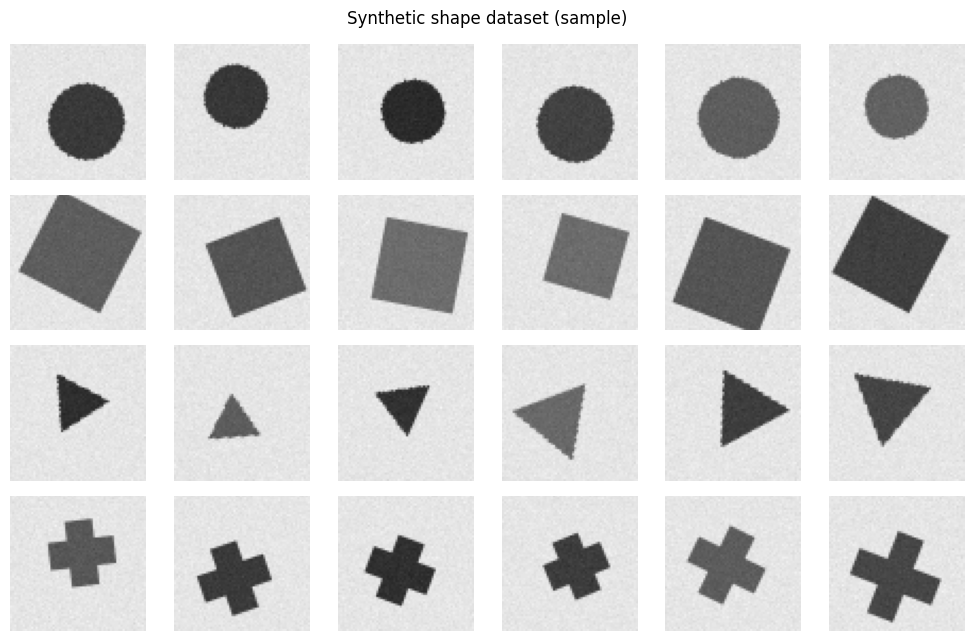

In [4]:
# Synthetic dataset generator: 4 classes of shapes, with random rotation, position, and noise
IMG_SIZE = 64
CLASSES = ["circle", "square", "triangle", "cross"]
RNG = np.random.default_rng(0)


def make_shape(label: int, size: int = IMG_SIZE) -> np.ndarray:
    img = np.full((size, size), 230, dtype=np.uint8)

    # Random center (slight jitter), random size, random color (intensity)
    cx = size // 2 + RNG.integers(-6, 7)
    cy = size // 2 + RNG.integers(-6, 7)
    radius = RNG.integers(14, 22)
    color = int(RNG.integers(40, 110))

    if label == 0:   # circle
        cv2.circle(img, (cx, cy), radius, color, -1)
    elif label == 1:   # square
        half = radius
        cv2.rectangle(img, (cx-half, cy-half), (cx+half, cy+half), color, -1)
    elif label == 2:   # triangle (random orientation)
        angle = RNG.uniform(0, 2 * np.pi)
        pts = []
        for i in range(3):
            a = angle + i * 2 * np.pi / 3
            pts.append([cx + int(radius * np.cos(a)), cy + int(radius * np.sin(a))])
        pts = np.array(pts, dtype=np.int32)
        cv2.fillPoly(img, [pts], color)
    elif label == 3:   # cross (plus sign)
        thickness = 6
        cv2.rectangle(img, (cx-radius, cy-thickness), (cx+radius, cy+thickness), color, -1)
        cv2.rectangle(img, (cx-thickness, cy-radius), (cx+thickness, cy+radius), color, -1)

    # Optional small rotation for ALL classes
    angle_deg = RNG.uniform(-30, 30)
    M = cv2.getRotationMatrix2D((size/2, size/2), angle_deg, 1.0)
    img = cv2.warpAffine(img, M, (size, size), borderValue=230)

    # Add a little Gaussian noise
    img = np.clip(img + RNG.normal(0, 4, img.shape), 0, 255).astype(np.uint8)
    return img


def make_dataset(n_per_class: int):
    X, y = [], []
    for label in range(len(CLASSES)):
        for _ in range(n_per_class):
            X.append(make_shape(label))
            y.append(label)
    return np.array(X), np.array(y)


X_train, y_train = make_dataset(n_per_class=300)
X_test, y_test = make_dataset(n_per_class=100)

print(f"Train: {X_train.shape}  labels: {y_train.shape}")
print(f"Test:  {X_test.shape}   labels: {y_test.shape}")
print(f"Classes: {CLASSES}")

# Show a 4x4 grid of training samples (one row per class)
fig, axes = plt.subplots(4, 6, figsize=(10, 6.5))
for row, cls in enumerate(CLASSES):
    idxs = np.where(y_train == row)[0][:6]
    for col, i in enumerate(idxs):
        axes[row, col].imshow(X_train[i], cmap="gray", vmin=0, vmax=255)
        axes[row, col].axis("off")
        if col == 0:
            axes[row, col].set_ylabel(cls, rotation=0, fontsize=11, labelpad=30)
plt.suptitle("Synthetic shape dataset (sample)")
plt.tight_layout()
plt.show()

## 4. Baseline - KNN on Raw Pixels

Before any clever feature engineering, run the dumbest possible classifier: flatten each image into a 4096-dim vector (64*64) and use K-Nearest Neighbors.

This sets the floor. Anything better has to beat it.


In [5]:
# Flatten each image into a vector
X_train_flat = X_train.reshape(len(X_train), -1).astype(np.float32) / 255.0
X_test_flat = X_test.reshape(len(X_test), -1).astype(np.float32) / 255.0

print(f"Flattened train shape: {X_train_flat.shape}")

# Train a 5-NN classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_flat, y_train)

# Evaluate
acc_pixels = knn.score(X_test_flat, y_test)
print(f"\nKNN on raw pixels - test accuracy: {acc_pixels*100:.1f}%")

y_pred = knn.predict(X_test_flat)
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=CLASSES, digits=3))

Flattened train shape: (1200, 4096)

KNN on raw pixels - test accuracy: 88.8%

Classification report:
              precision    recall  f1-score   support

      circle      0.695     0.980     0.813       100
      square      0.974     0.740     0.841       100
    triangle      1.000     0.970     0.985       100
       cross      1.000     0.860     0.925       100

    accuracy                          0.887       400
   macro avg      0.917     0.887     0.891       400
weighted avg      0.917     0.887     0.891       400



## 5. HOG + Linear SVM - The Classical Recipe

Now upgrade to the famous Dalal-Triggs recipe: **HOG features + Linear SVM**. Same dataset, same train/test split - we'll see how much shape-aware features help.

### Why a Linear SVM?

- Fast to train and predict
- Works well in **high-dimensional** spaces (HOG produces ~hundreds of features per image)
- Provides a margin-based decision boundary that generalizes
- Easily interpretable weight vector


In [6]:
# Compute HOG features for the entire dataset
def compute_hog_features(images, orientations=9, pixels_per_cell=(8, 8),
                        cells_per_block=(2, 2)):
    feats = []
    for img in images:
        f = hog(
            img,
            orientations=orientations,
            pixels_per_cell=pixels_per_cell,
            cells_per_block=cells_per_block,
            block_norm="L2-Hys",
            visualize=False,
        )
        feats.append(f)
    return np.array(feats)


X_train_hog = compute_hog_features(X_train)
X_test_hog = compute_hog_features(X_test)

print(f"HOG features shape: {X_train_hog.shape}")
print(f"That's {X_train_hog.shape[1]} HOG dims vs {X_train_flat.shape[1]} raw-pixel dims")
print(f"Compression ratio: {X_train_flat.shape[1] / X_train_hog.shape[1]:.1f}x smaller")

HOG features shape: (1200, 1764)
That's 1764 HOG dims vs 4096 raw-pixel dims
Compression ratio: 2.3x smaller


In [7]:
# Standardize HOG features (always a good idea before SVM)
scaler = StandardScaler()
X_train_hog_s = scaler.fit_transform(X_train_hog)
X_test_hog_s = scaler.transform(X_test_hog)

# Train a Linear SVM
svm = LinearSVC(C=1.0, max_iter=5000, dual="auto")
svm.fit(X_train_hog_s, y_train)

acc_hog = svm.score(X_test_hog_s, y_test)
print(f"HOG + Linear SVM - test accuracy: {acc_hog*100:.1f}%")
print(f"(Compare with raw-pixel KNN: {acc_pixels*100:.1f}%)")

y_pred_hog = svm.predict(X_test_hog_s)
print("\nClassification report:")
print(classification_report(y_test, y_pred_hog, target_names=CLASSES, digits=3))

HOG + Linear SVM - test accuracy: 97.2%
(Compare with raw-pixel KNN: 88.8%)

Classification report:
              precision    recall  f1-score   support

      circle      0.990     1.000     0.995       100
      square      1.000     0.970     0.985       100
    triangle      0.933     0.970     0.951       100
       cross      0.969     0.950     0.960       100

    accuracy                          0.973       400
   macro avg      0.973     0.972     0.973       400
weighted avg      0.973     0.973     0.973       400



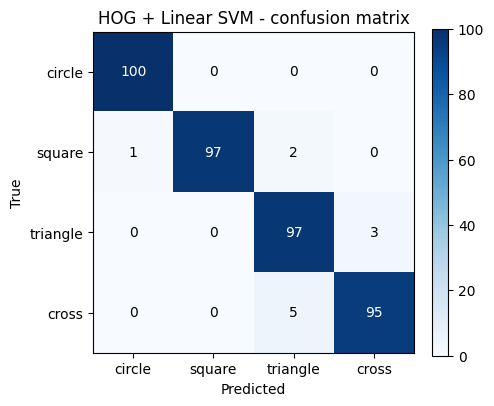

In [8]:
# Confusion matrix for the HOG+SVM model
cm = confusion_matrix(y_test, y_pred_hog)

fig, ax = plt.subplots(figsize=(5, 4.5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(len(CLASSES)))
ax.set_yticks(range(len(CLASSES)))
ax.set_xticklabels(CLASSES)
ax.set_yticklabels(CLASSES)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("HOG + Linear SVM - confusion matrix")

# Annotate counts
for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

## 6. Bag-of-Visual-Words (BoVW)

HOG slices each image into a fixed grid - it doesn't handle different object sizes or positions well. **Bag-of-Visual-Words** (Sivic & Zisserman, 2003) is the classical fix.

### The idea (borrowed from text retrieval)

In NLP, you turn a document into a histogram of word counts. BoVW does the same for images:

```
1. For every training image, extract LOCAL descriptors (SIFT / ORB)
2. K-means cluster ALL of them into K "visual words" (the codebook / vocabulary)
3. For each new image: extract descriptors, assign each to its nearest visual word,
   build a histogram of word counts
4. Train any classifier (SVM, RF) on these histograms
```

### Why it works

- The histogram has **fixed length K** regardless of image size or descriptor count
- It's translation- and somewhat rotation-invariant (descriptors are local)
- It's the bridge that powered the 2003-2012 image-retrieval era (and is still used in mobile/edge today)


In [9]:
# BoVW pipeline using ORB descriptors (faster than SIFT for many images)
orb = cv2.ORB_create(nfeatures=80)


def extract_local_descriptors(images):
    """Return list of (N_keypoints, 32) ORB descriptor arrays."""
    all_desc = []
    for img in images:
        _, des = orb.detectAndCompute(img, None)
        if des is None:
            des = np.zeros((1, 32), dtype=np.uint8)   # placeholder
        all_desc.append(des)
    return all_desc


# Step 1: extract descriptors for every training image
print("Step 1/4: Extracting ORB descriptors from training set...")
train_descs = extract_local_descriptors(X_train)
test_descs = extract_local_descriptors(X_test)

total_train_descs = sum(len(d) for d in train_descs)
print(f"Total training descriptors: {total_train_descs}")
print(f"Avg per image: {total_train_descs / len(X_train):.1f}")

# Step 2: stack all training descriptors and run K-means to build the codebook
print("\nStep 2/4: Building visual vocabulary with K-Means...")
all_train_descs = np.vstack(train_descs).astype(np.float32)
K = 50   # vocabulary size

kmeans = MiniBatchKMeans(n_clusters=K, random_state=0, n_init=3, batch_size=512)
kmeans.fit(all_train_descs)
print(f"Codebook shape: {kmeans.cluster_centers_.shape}  (K={K} visual words)")

Step 1/4: Extracting ORB descriptors from training set...
Total training descriptors: 1200
Avg per image: 1.0

Step 2/4: Building visual vocabulary with K-Means...
Codebook shape: (50, 32)  (K=50 visual words)


Step 3/4: Building BoVW histograms for every image...
BoVW train features: (1200, 50)
BoVW test features:  (400, 50)


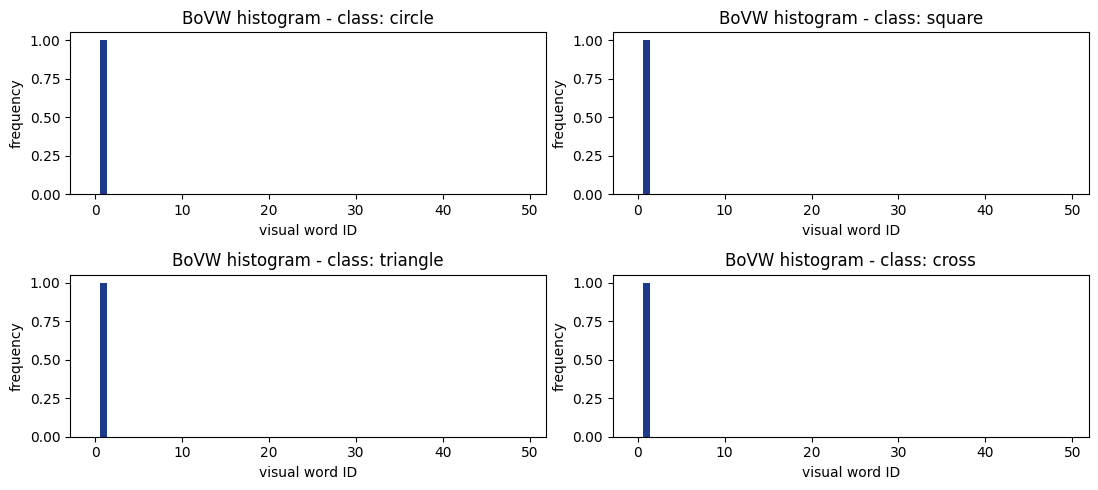

In [10]:
# Step 3: turn each image into a histogram of visual words
def build_bovw_histogram(descs, kmeans, K):
    if len(descs) == 0:
        return np.zeros(K, dtype=np.float32)
    words = kmeans.predict(descs.astype(np.float32))
    hist, _ = np.histogram(words, bins=np.arange(K + 1))
    # L1-normalize so total counts don't dominate
    if hist.sum() > 0:
        hist = hist / hist.sum()
    return hist.astype(np.float32)


print("Step 3/4: Building BoVW histograms for every image...")
X_train_bovw = np.array([build_bovw_histogram(d, kmeans, K) for d in train_descs])
X_test_bovw = np.array([build_bovw_histogram(d, kmeans, K) for d in test_descs])

print(f"BoVW train features: {X_train_bovw.shape}")
print(f"BoVW test features:  {X_test_bovw.shape}")

# Visualize a histogram for one sample of each class
fig, axes = plt.subplots(2, 2, figsize=(11, 5))
for ax, cls_idx in zip(axes.ravel(), range(4)):
    sample_idx = np.where(y_train == cls_idx)[0][0]
    ax.bar(np.arange(K), X_train_bovw[sample_idx], color="#1e3a8a")
    ax.set_title(f"BoVW histogram - class: {CLASSES[cls_idx]}")
    ax.set_xlabel("visual word ID")
    ax.set_ylabel("frequency")
plt.tight_layout()
plt.show()

In [11]:
# Step 4: train an SVM on the BoVW histograms
print("Step 4/4: Training SVM on BoVW histograms...")
svm_bovw = SVC(kernel="rbf", C=10, gamma="scale")
svm_bovw.fit(X_train_bovw, y_train)

acc_bovw = svm_bovw.score(X_test_bovw, y_test)
print(f"\nBoVW + RBF-SVM - test accuracy: {acc_bovw*100:.1f}%")

# Final score comparison
print("\nMethod comparison:")
print(f"  KNN on raw pixels   : {acc_pixels*100:5.1f}%")
print(f"  HOG + Linear SVM    : {acc_hog*100:5.1f}%")
print(f"  BoVW (ORB) + RBF SVM: {acc_bovw*100:5.1f}%")
print("\nNote: BoVW shines on cluttered natural images;")
print("for clean shapes, dense HOG is hard to beat.")

Step 4/4: Training SVM on BoVW histograms...

BoVW + RBF-SVM - test accuracy: 25.2%

Method comparison:
  KNN on raw pixels   :  88.8%
  HOG + Linear SVM    :  97.2%
  BoVW (ORB) + RBF SVM:  25.2%

Note: BoVW shines on cluttered natural images;
for clean shapes, dense HOG is hard to beat.


## 7. Sliding-Window Detection - The OG Object Detection

So far we've **classified** whole images. Real detection asks: *where in this big image is my object?*

Before YOLO and Faster R-CNN, the answer was: **slide a fixed-size window over the image, run the classifier at every position, keep the high-confidence boxes**. This is exactly what Viola-Jones and HOG+SVM pedestrian detection did.

### The pipeline

```
For each window position (x, y):
  Crop a 64x64 patch
  Compute HOG features
  Run SVM -> score
  If score > threshold: record box
After loop: Non-Maximum Suppression (NMS) to remove duplicate boxes
```


In [12]:
# Train a 2-class detector: "circle" vs "background"
# We already have circles in X_train (label 0). Add a background class.
positive_idx = np.where(y_train == 0)[0]   # circles
negative_idx = np.where(y_train != 0)[0]   # other shapes act as 'background'

X_pos = X_train[positive_idx]   # ~300 circles
X_neg = X_train[negative_idx][:300]   # 300 negatives

X_det = np.concatenate([X_pos, X_neg])
y_det = np.array([1] * len(X_pos) + [0] * len(X_neg))

# HOG + Linear SVM detector
X_det_hog = compute_hog_features(X_det)
scaler_det = StandardScaler().fit(X_det_hog)
X_det_hog_s = scaler_det.transform(X_det_hog)

detector = LinearSVC(C=1.0, max_iter=5000, dual="auto")
detector.fit(X_det_hog_s, y_det)
print(f"Detector trained on {len(X_det)} samples ({len(X_pos)} positives, {len(X_neg)} negatives)")
print(f"Train accuracy: {detector.score(X_det_hog_s, y_det)*100:.1f}%")

Detector trained on 600 samples (300 positives, 300 negatives)
Train accuracy: 100.0%


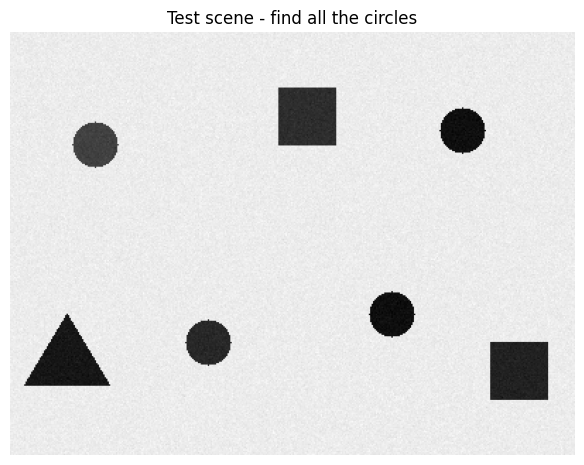

In [13]:
# Build a 'scene' image with multiple shapes scattered around
np.random.seed(7)
scene = np.full((300, 400), 235, dtype=np.uint8)

# Place circles at a few random spots
circle_centers = [(60, 80), (320, 70), (140, 220), (270, 200)]
for (cx, cy) in circle_centers:
    cv2.circle(scene, (cx, cy), 16, int(np.random.randint(40, 90)), -1)

# Distractors (squares, triangles)
cv2.rectangle(scene, (190, 40), (230, 80), 70, -1)
pts = np.array([[40, 200], [70, 250], [10, 250]], dtype=np.int32)
cv2.fillPoly(scene, [pts], 50)
cv2.rectangle(scene, (340, 220), (380, 260), 60, -1)

scene = np.clip(scene + np.random.normal(0, 4, scene.shape), 0, 255).astype(np.uint8)

plt.figure(figsize=(8, 5.5))
plt.imshow(scene, cmap="gray")
plt.title("Test scene - find all the circles")
plt.axis("off")
plt.show()

Total windows scored: 1290
Windows above threshold: 28


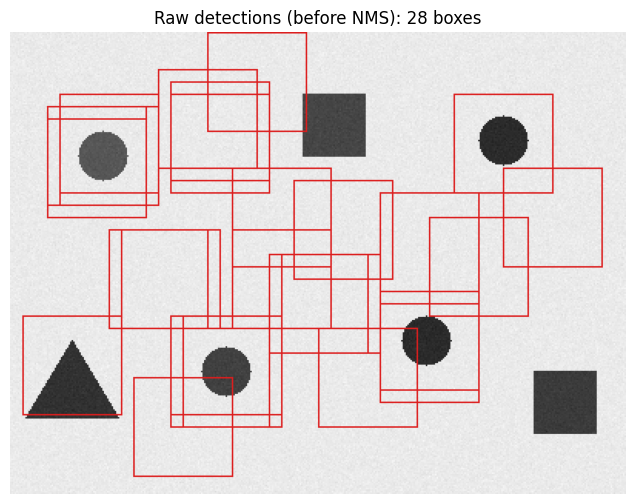

In [14]:
# Sliding-window inference
WINDOW = 64
STRIDE = 8
boxes = []   # (x, y, score)

for y in range(0, scene.shape[0] - WINDOW + 1, STRIDE):
    for x in range(0, scene.shape[1] - WINDOW + 1, STRIDE):
        patch = scene[y:y+WINDOW, x:x+WINDOW]
        feat = hog(patch, orientations=9, pixels_per_cell=(8, 8),
                  cells_per_block=(2, 2), block_norm="L2-Hys")
        feat_s = scaler_det.transform(feat.reshape(1, -1))
        score = detector.decision_function(feat_s)[0]
        if score > 0.3:   # tunable threshold
            boxes.append((x, y, float(score)))

print(f"Total windows scored: "
      f"{((scene.shape[0]-WINDOW)//STRIDE+1) * ((scene.shape[1]-WINDOW)//STRIDE+1)}")
print(f"Windows above threshold: {len(boxes)}")

# Visualize raw detections (before NMS)
vis = cv2.cvtColor(scene, cv2.COLOR_GRAY2RGB)
for (x, y, s) in boxes:
    cv2.rectangle(vis, (x, y), (x+WINDOW, y+WINDOW), (220, 30, 30), 1)

plt.figure(figsize=(9, 6))
plt.imshow(vis)
plt.title(f"Raw detections (before NMS): {len(boxes)} boxes")
plt.axis("off")
plt.show()

### 7.1 - Non-Maximum Suppression (NMS)

A single object usually triggers many overlapping windows. NMS keeps the highest-scoring box and suppresses anything that overlaps with it too much (high **IoU**).

```
Sort boxes by score (descending)
Take the top box, add it to "kept"
Remove any remaining box whose IoU with the top box > threshold
Repeat until no boxes left
```


After NMS: 28 -> 16 boxes


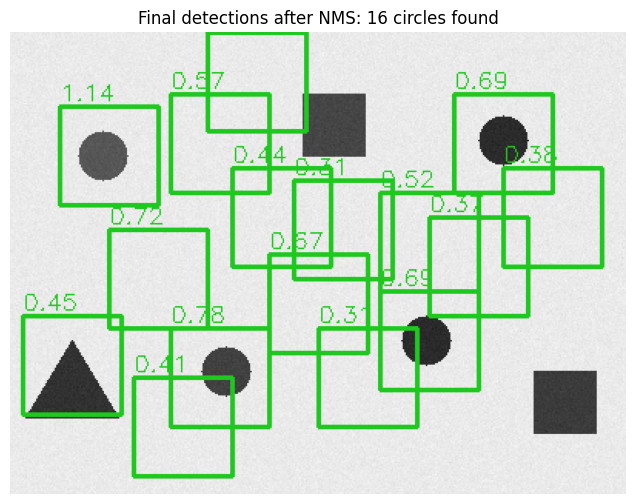


This is the same logic that powered HOG+SVM pedestrian detection in 2005-2012.
Modern detectors (YOLO, DETR) replace the sliding window with a single forward pass.


In [15]:
def iou(box_a, box_b):
    """IoU between two boxes given as (x, y, w, h)."""
    ax1, ay1, aw, ah = box_a
    bx1, by1, bw, bh = box_b
    ax2, ay2 = ax1 + aw, ay1 + ah
    bx2, by2 = bx1 + bw, by1 + bh

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)
    inter_area = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)

    union_area = aw * ah + bw * bh - inter_area
    return inter_area / union_area if union_area > 0 else 0


def nms(boxes_with_scores, iou_thresh=0.3):
    """Non-maximum suppression."""
    boxes = sorted(boxes_with_scores, key=lambda b: b[2], reverse=True)
    kept = []
    while boxes:
        head = boxes.pop(0)
        kept.append(head)
        head_box = (head[0], head[1], WINDOW, WINDOW)
        boxes = [b for b in boxes
                 if iou(head_box, (b[0], b[1], WINDOW, WINDOW)) < iou_thresh]
    return kept


final = nms(boxes, iou_thresh=0.3)
print(f"After NMS: {len(boxes)} -> {len(final)} boxes")

vis2 = cv2.cvtColor(scene, cv2.COLOR_GRAY2RGB)
for (x, y, s) in final:
    cv2.rectangle(vis2, (x, y), (x+WINDOW, y+WINDOW), (30, 200, 30), 2)
    cv2.putText(vis2, f"{s:.2f}", (x, y - 4),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (30, 200, 30), 1)

plt.figure(figsize=(9, 6))
plt.imshow(vis2)
plt.title(f"Final detections after NMS: {len(final)} circles found")
plt.axis("off")
plt.show()

print("\nThis is the same logic that powered HOG+SVM pedestrian detection in 2005-2012.")
print("Modern detectors (YOLO, DETR) replace the sliding window with a single forward pass.")

## 8. When Classical ML Falls Apart

To set up the next notebook, here's what classical methods **can't** do well:

| Failure mode | Why classical struggles |
|---|---|
| **Cluttered backgrounds** | HOG fires on every edge; the SVM sees noise |
| **Large intra-class variation** (cats: tabby, sphynx, persian, kitten...) | A single descriptor can't span them all |
| **Many classes** (100+ ImageNet categories) | Hand-designed features lose discriminative power |
| **Fine-grained detail** (dog breed, bird species) | Need *learned* features that focus on subtle parts |
| **End-to-end learning** | Classical = fixed features + trainable head; deep learning trains both |

This is exactly why deep learning won in 2012. **AlexNet** crushed ImageNet because it learned features and classifier together.

But classical methods didn't die - they just retreated to:

- Embedded / edge devices
- Small-data regimes
- Interpretability-required domains
- The **preprocessing layer** of modern deep pipelines (you'll see HOG-like features inside many CNNs early layers)


## 9. Recap

- **Classical ML still matters in 2026** for small data, edge devices, latency-critical, interpretable systems
- **HOG** captures shape via gradient orientation histograms - the workhorse descriptor
- **KNN on raw pixels** is the floor every method must beat
- **HOG + Linear SVM** - the Dalal-Triggs classical recipe
- **BoVW (Bag-of-Visual-Words)** - turn local features into global histograms
- **Sliding window + NMS** - the OG object-detection pattern (still useful for understanding YOLO)
- **Trained 3 models on the same dataset** and built a real shape detector with NMS

### One-line takeaway

> **Hand-designed features + a good classifier still solve a surprising amount of CV - and even when they don't, understanding HOG/SVM/BoVW is the only way to truly appreciate what deep learning replaced.**

---

### Coming next: Notebook 06 - Deep Learning for CV (CNNs from scratch)

We'll go deep on:

- The neuron, the layer, the activation function
- Convolution as a learnable operation (compare to Notebook 03)
- Pooling, padding, stride - the geometric building blocks
- Backprop intuition without heavy math
- Build LeNet from scratch in PyTorch and train it on our shape dataset
- Why CNNs beat HOG: visualize what the network actually learns

---

<div style="background:linear-gradient(135deg,#0f172a 0%,#1e3a8a 100%);padding:18px;border-radius:10px;color:white;text-align:center;font-family:'Segoe UI',sans-serif;margin-top:18px;">
<b>End of Notebook 05 - Computer Vision Series - 2025-2026</b><br>
<span style="opacity:0.8;font-size:13px;">Classical foundations locked in. Next stop: networks that learn their own features.</span>
</div>